# Final California House Price Modeling

This notebook turns the corrected command-line workflow into a guided analysis.
It predicts district median house values from the California Housing dataset.
The project is educational and does not provide property valuations.

## 1. Load data

Scikit-learn downloads the public dataset on first use and caches it locally.
Keeping the loader in code avoids committing a duplicate data file to Git.

In [1]:
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from housing_model import build_pipeline, evaluate_predictions, feature_importance, split_data

RANDOM_STATE = 42
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
print(f"Rows: {len(X):,} | Features: {X.shape[1]} | Target unit: $100,000s")
X.head()

Rows: 20,640 | Features: 8 | Target unit: $100,000s


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 2. Exploratory data analysis

We inspect target distribution and feature correlations before fitting. These plots
identify data characteristics; they do not prove that any feature causes price.

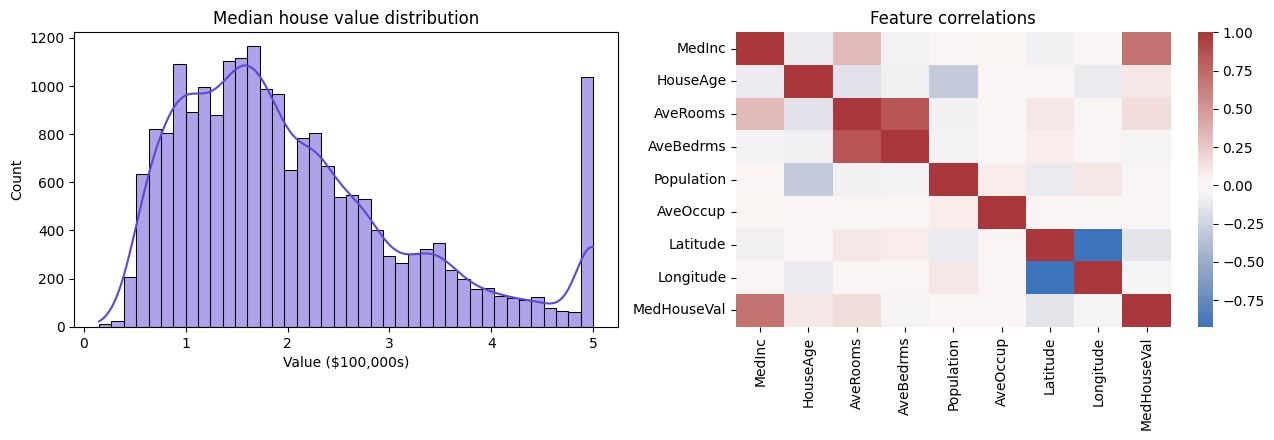

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(y, bins=40, kde=True, ax=axes[0], color="#6046d7")
axes[0].set(title="Median house value distribution", xlabel="Value ($100,000s)")
sns.heatmap(pd.concat([X, y.rename("MedHouseVal")], axis=1).corr(), cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Feature correlations")
fig.tight_layout()
plt.show()

## 3. Leakage-safe training pipeline

The split happens before imputation and scaling. The pipeline then learns those
transformations only from training rows, preserving the test set as unseen data.

In [3]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=RANDOM_STATE)
pipeline = build_pipeline(random_state=RANDOM_STATE)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
metrics = evaluate_predictions(y_test, predictions)
pd.DataFrame([metrics], index=["Random forest baseline"]).round(3)

,mae,rmse,r2
Random forest baseline,0.326,0.504,0.806


## 4. Evaluate errors

MAE reports typical error, RMSE highlights large misses, and R² describes the
fraction of holdout variation captured by the model. All three are needed.

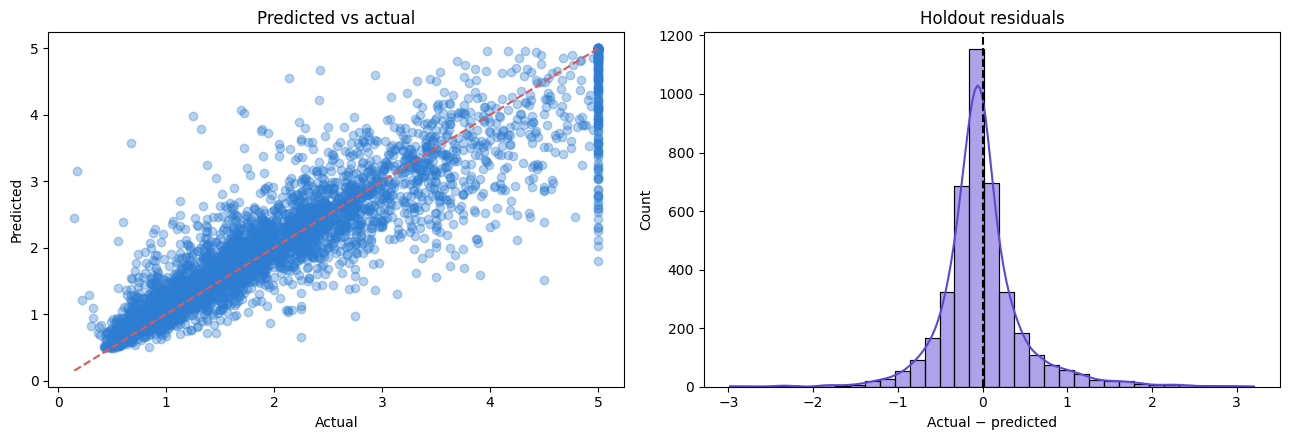

In [4]:
residuals = y_test - predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_test, predictions, alpha=.35, color="#2d7dd2")
limits = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
axes[0].plot(limits, limits, "--", color="#e45756")
axes[0].set(title="Predicted vs actual", xlabel="Actual", ylabel="Predicted")
sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color="#6046d7")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Holdout residuals", xlabel="Actual − predicted")
fig.tight_layout()
plt.show()

## 5. Feature importance and limitations

Importance ranks how strongly this fitted forest relied on each feature. It is not
causal evidence. Historical data, local-market variation, and distribution drift
mean this project must not be used as a production valuation system.

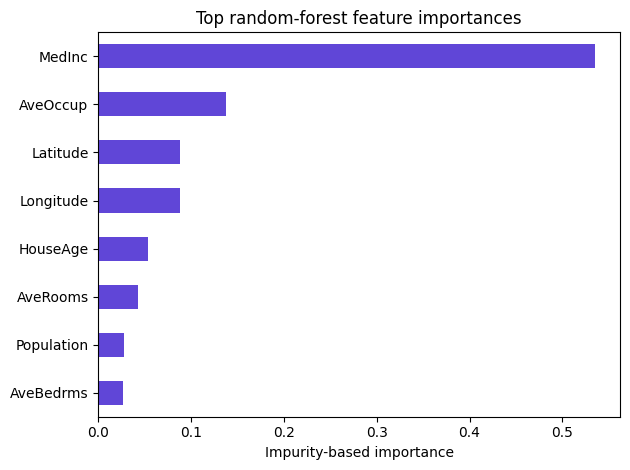

In [5]:
importance = pd.Series(feature_importance(pipeline, list(X.columns))).head(8).sort_values()
importance.plot.barh(color="#6046d7", title="Top random-forest feature importances")
plt.xlabel("Impurity-based importance")
plt.tight_layout()
plt.show()